<h1>Scikit-Learn Pipelines</h1>
<p>A Pipeline is simply a mini-conveyor belt. Instead of manually running your data through an imputer, then a scaler, then an encoder, and finally passing it to your machine learning model, a Pipeline links all these steps into a single, unified object.

The pipeline is programmed to blindly pass the dataset (X) to the fit method of every tool on the belt. When you build a Pipeline, it strictly enforces order:</p>

<ul>
    <li><b>Intermediate Steps:</b> Every step before the end must be a "Transformer" (a tool that has both .fit() and .transform() methods, like StandardScaler or SimpleImputer).</li>
    <li><b>The Final Step:</b> The last step is usually an "Estimator" (a machine learning model, like LogisticRegression or RandomForestClassifier that has a .fit() and .predict() method)</li>
</ul>

<h2>Why Are Pipelines Mandatory in the Industry?</h2>
<ol>
    <li><b>Prevents Data Leakage:</b> This is the most critical benefit. When you use cross-validation or split your data, a Pipeline ensures that your tools (like scalers) only learn the math from the training folds, never the testing folds.</li>
    <li><b>Cleaner Code:</b> You replace dozens of lines of messy, intermediate variables (e.g., X_train_scaled_encoded) with a single .fit() command.</li>
    <li><b>Deployment Ready:</b> When you save your final model to put it into a production app, the Pipeline saves the preprocessing steps inside the model. When a user inputs raw data, the Pipeline automatically cleans, scales, and predicts in one motion.</li>
</ol>

## The Two Fundamental Building Blocks
| Job                 | Name        |
| ------------------- | ----------- |
| Changes data        | Transformer |
| Learns and predicts | Estimator   |

`Everything in pipelines is built on this distinctions`  

### What is a Transformer?
* A `Transformer` is an object that **takes data as input and returns modified data as output**.

### What is an  Estimator?
* An `Estimator` is an object that learns patterns from training data and can make predictions (or otherwise fit a model)

----------------------------------------------------------------------------
* A transformer learns `how to transform` the data
* An estimator learns `how to make predictions` from the data

-----------------------------------------------------------------------------
### Summary
| Transformer                                                  | Estimator                                                                          |
| ------------------------------------------------------------ | ---------------------------------------------------------------------------------- |
| Changes data                                                 | Learns from data                                                                   |
| Produces transformed data                                    | Produces a trained model and predictions                                           |
| Uses `fit()` and `transform()`                               | Uses `fit()` and `predict()`                                                       |
| Examples: `StandardScaler`, `SimpleImputer`, `OneHotEncoder` | Examples: `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier` |
------------------------------------------------------------------------------
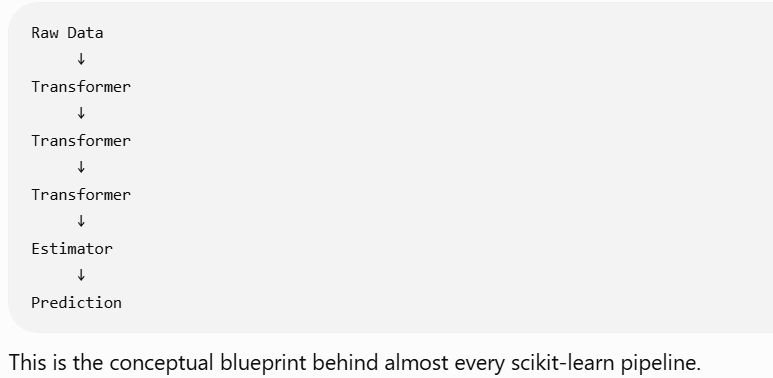


## Building The First Scikit-learn Pipeline

#### Step 1: Import the Required Classes

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#### Step 2: Create the Pipeline

In [3]:
pipeline = Pipeline([
    # name, object
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

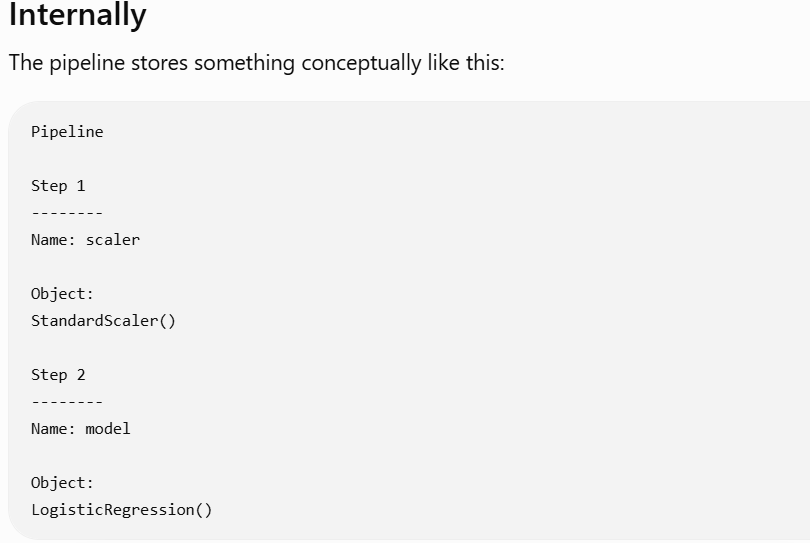

#### Step 3: Train the Pipeline

In [5]:
# suppose we already have X_train, and y_train
X_train
y_train

pipeline.fit(X_train,y_train)

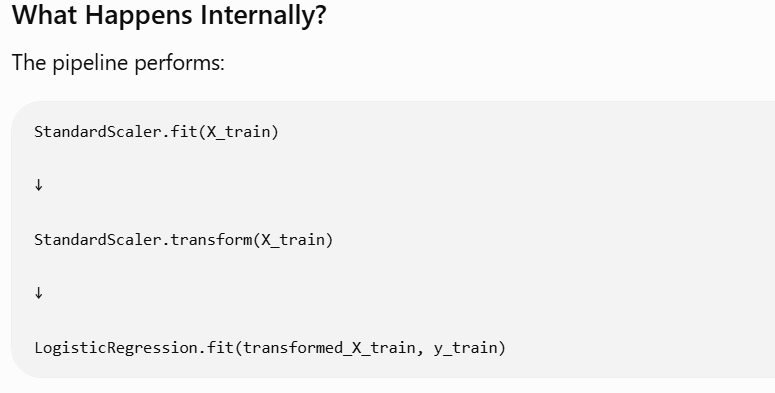

#### Step 4: Predict

In [ ]:
predictions = pipeline.predict(X_test)

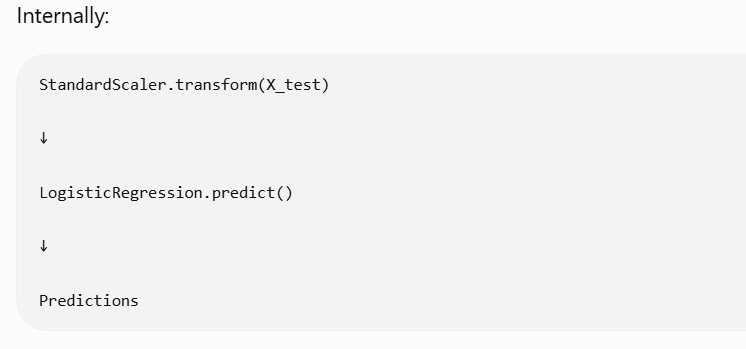

##### Practice Exercise

Write code that:

1. Imports:
    * `Pipeline`
    * `MinMaxScaler`
    * `DecisionTreeClassifier`
2. Creates a pipeline named `my_pipeline`.
3. Uses these steps in order:
    * `"scaler"` → `MinMaxScaler()`
    * `"classifier"` → `DecisionTreeClassifier()`

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

In [7]:
my_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', DecisionTreeClassifier())
])

## Nested Pipelines (Pipeline Inside a Pipeline)
Supppose the datasete is:  
| Age | Salary | Gender | City       | Purchased |
| --- | ------ | ------ | ---------- | --------- |
| 25  | 35000  | Male   | Dhaka      | Yes       |
| ?   | 50000  | Female | Khulna     | No        |
| 40  | ?      | Male   | Chattogram | Yes       |  

The `age and salary` columns have missing values and need scaling  
So the numeric workflow becomes:  **Age, Salary => Fill Missing Values => Scale Values**  

So, there are **multiple preprocessing steps** for the same group of columns. A single transformer can't perform two different transformations in sequence  

`ColumnTransformer` expects **one transformer per column group**

### The Solution: A Pipeline as the Transformer

#### Step 1: Numeric Pipeline

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
])

#### Step 2: Categorical Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

#### Step 3: ColumnTransformer

In [3]:
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, ['Age','Salary']),
    ('cat', categorical_pipeline, ['Gender', 'City'])
])

#### Step 4: Final Pipeline

In [4]:
from sklearn.linear_model import LogisticRegression
model = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', LogisticRegression())
])

## GridSEarchCV
`A Scikit-Learn function used to automate the process of hyperparameter tuning for machine learning models`. It performs an exhaustive search over a predefined grid of parameter vlaues, evaluating every combination using cross-validation to identify the model configuaration that yields the highest performance  

------------------------------------------------------------------------------
Key Components of `GridSearchCV`  
* **Estimator:** The machine learning model to be tuned.  
* **Param_grid:** Dictionary specifying the parameter grid to be searched.  
* **Scoring:** Metric used to evaluate model performance.  
* **CV:** Cross-validation strategy.  

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier())
])

# define the parameter grid
param_grid = {
    'classifier__max_depth':[2,5,10],
    'classifier__min_samples_split':[2,4,8]
}

# set up the grid search object
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5
)

# fit the data
grid.fit(X_train,y_train)

# view the best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

## Cross-Validation
A `statistical technique used in machine learning to evaluate how well a model generalizes to unseen data`. It systematically splits the available data into multiple training and testing sets, iteratively trains and tests the model on these subsets, and averages the results to ensure a robust, unbiased performance estimate  

### Why Cross-Validation?
* **Prevents Overfitting**: by rotating the data used for training and testing, the model is exposed to varied examples, preventing it from just "memorizing" one specific subset
* **Maximizes Limited Data**: unlike  a standard 80/20 holdout split where some data is never used for training, cross-validation ensures every data point is used for both training and validation
* **Hyperparameter Tuning**: it  It is extensively used to test different model configurations to find the optimal settings

### Common Types of Cross-Validation
* **K-Fold**: the  dataset is divided into k equal-sized subsets ("folds"). The model is trained on k-1 folds and tested on the remaining fold, rotating until every fold has been used for testing. (A typical choice is 10-fold)
* **Stratified K-Fold**: similar  dataset is divided into k equal-sized subsets ("folds"). The model is trained on k-1 folds and tested on the remaining fold, rotating until every fold has been used for testing. (A typical choice is 10-fold)
* **Leave-One-Out (LOOCV)**: a  A special case of K-Fold where k equals the total number of data points in the dataset. In each iteration, the model is trained on all but one data point and tested on that single left-out point. It is useful for very small datasets
* **Time Series Split**: used for  Used for sequential data where the order of observations matters. It trains on past data to predict future data without looking into the future (avoids temporal leakage)

## Custom Transformer
Scikit-learn provides many transformers, but if your project requieres something unique for that scikit-learn has no built-in transformer, we define our own transformer.   

This is possible because scikit-learn expects every trnasformer to follow the same interface: `fit() and transform()`  

------------------------------------------------------------------------------
### The Base Classes
Mos custom transformers inherit from:
* `BaseEstimator`
* `TransformerMixin`

They provide the behavior that makes your class compatible with the rest of scikit-learn

### The Skeleton

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class MyTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y = None):
        return sef

    def transform(self, X):
        return X

#### Best Practices
A good custom transformer should:  
* Perform one clear task.
* Avoid modifying the original input in place.
* Return transformed data.
* Store anything learned during fit() as instance attributes (for example, self.mean_).